## ZFP

ZFP [^1] is a high-throughput transform-based compressor for n-dimensional floating-point and integer data, which compresses the data in independent $4 \times \ldots \times 4$ blocks. The values inside a block are rescaled, decorrelated, and transformed into a bit stream that can be truncated at any point to select the desired quality.

ZFP supports several compression modes, including (1) targeting a specific compression ratio, (2) bounding the pointwise absolute error, or (3) losslessly compressing the data, and more. You can find out more about the other modes at <https://zfp.readthedocs.io/en/release1.0.1/modes.html>.

We use ZFP v1.0.1 with the `ZFP_ROUNDING_MODE=ZFP_ROUND_FIRST` and `ZFP_WITH_TIGHT_ERROR=ON` settings, also known as ZFP-ROUND [^2], which produces unbiased compression errors and higher compression ratios.

[1]: Lindstrom, P. (2014). Fixed-Rate Compressed Floating-Point arrays. *IEEE Transactions on Visualization and Computer Graphics*, 20(12), 2674–2683. Available from: [doi:10.1109/tvcg.2014.2346458](https://doi.org/10.1109/tvcg.2014.2346458).

[2]: Hammerling, D. M., Baker, A. H., Pinard, A., & Lindstrom, P. (2019). A Collaborative Effort to Improve Lossy Compression Methods for Climate Data. *2019 IEEE/ACM 5th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-5)*, 16–22. Available from: [doi:10.1109/drbsd-549595.2019.00008](https://doi.org/10.1109/drbsd-549595.2019.00008).

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

## Importing the `Zfp` compressor

In [4]:
from numcodecs_wasm_zfp import Zfp

In [5]:
?Zfp

Init signature:
Zfp(
    mode,
    _version='0.2.0',
    max_bits=None,
    max_prec=None,
    min_bits=None,
    min_exp=None,
    non_finite='deny',
    precision=None,
    rate=None,
    tolerance=None,
)
Docstring:     
Codec providing compression using ZFP

Parameters
----------
mode : ...
     - "expert": The most general mode, which can describe all four other modes
    
     - "fixed-rate": In fixed-rate mode, each d-dimensional compressed block of `$4^d$`
        values is stored using a fixed number of bits. This number of
        compressed bits per block is amortized over the `$4^d$` values to give
        a rate of `$rate = \frac{maxbits}{4^d}$` in bits per value.
    
     - "fixed-precision": In fixed-precision mode, the number of bits used to encode a block may
        vary, but the number of bit planes (the precision) encoded for the
        transform coefficients is fixed.
    
     - "fixed-accuracy": In fixed-accuracy mode, all transform coefficient bit planes up to

## Targeting a specific compression ratio

ZFP can target a specific compression ratio using

```python
cr = 10  # x10 compression

Zfp(mode="fixed-rate", rate=da.dtype.itemsize * 8 / cr)
```

## Bounding the pointwise absolute error

ZFP can bound the absolute error using

```python
Zfp(mode="fixed-accuracy", tolerance=eb_abs)
```

It is worth noting that ZFP often produces errors that are significantly below the error bound.

## Bounding the pointwise relative error

The easiest way to bound the pointwise relative error with ZFP is to transform the relative error bound into an absolute error bound [^3] using a metacompressor such as the `pw_rel_compressor_plugin` in LibPressio [^4] or the `numcodecs_pw_ratio.PointwiseRatioErrorBoundedCodec` port:

```python
from numcodecs_pw_ratio import PointwiseRatioErrorBoundedCodec
from numcodecs_wasm_zstd import Zstd

eb_rel = 0.01

PointwiseRatioErrorBoundedCodec(
    # transform pointwise relative error bound into pointwise ratio error bound
    eb_ratio=1+eb_rel,
    # mark how the absolute error is configured
    eb_abs_marker="$eb_abs",
    # lossy compressor that will use an absolute error bound
    log_codec={ **Zfp(mode="fixed-accuracy", tolerance=-1).get_config(), "tolerance": "$eb_abs" },
    # lossless compressor for compressing the data signs
    sign_codec=Zstd(level=3),
)
```

[3]: Liang, X., Di, S., Tao, D., Chen, Z., & Cappello, F. (2018). An Efficient Transformation Scheme for Lossy Data Compression with Point-Wise Relative Error Bound. *2018 IEEE International Conference on Cluster Computing (CLUSTER)*, 179–189. Available from: [doi:10.1109/cluster.2018.00036](https://doi.org/10.1109/cluster.2018.00036).

[4]: Underwood, R., Malvoso, V., Calhoun, J. C., Di, S., & Cappello, F. (2021). Productive and Performant Generic Lossy Data Compression with LibPressio. *2021 7th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-7)*, 1–10. Available from: [doi:10.1109/drbsd754563.2021.00005](https://doi.org/10.1109/drbsd754563.2021.00005).

## Preserving NaN Missing Values

ZFP does not yet support preserving infinite and NaN values during lossy compression. By default, the `non_finite="deny"` setting will raise an error when these values are encountered. It is also possible to pass `non_finite="allow-unsafe"` to encode data with these values, though this may cause undefined behaviour and produce incorrect values in the `4 \times \ldots \times 4` blocks that contain non-finite values.

## Example

In [6]:
# Load the data
ds = xr.open_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

In [7]:
eb_abs = 0.1  # 0.1 K

codec = Zfp(mode="fixed-accuracy", tolerance=eb_abs)

In [8]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

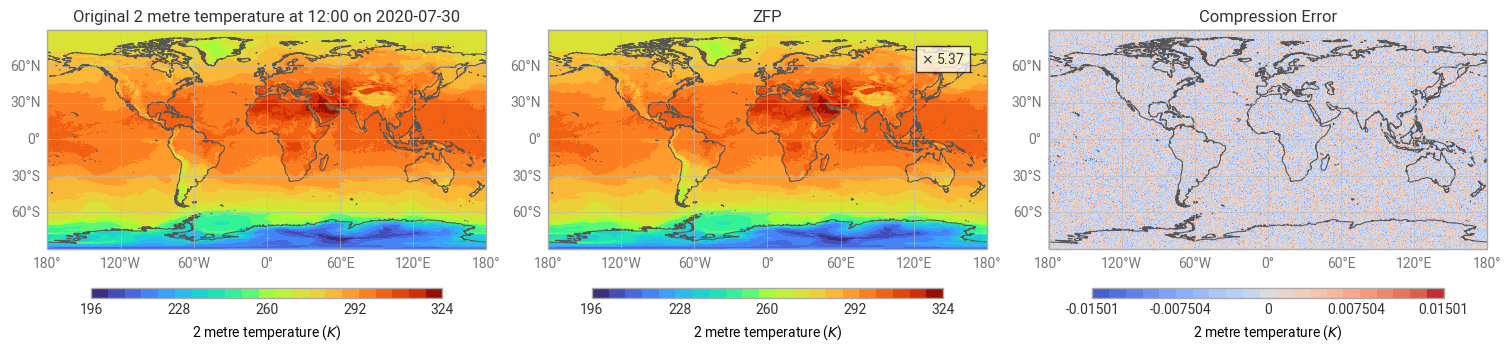

In [9]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec, fig.add_map(0, 1), title="ZFP", cr=da.nbytes / np.array(da_enc).nbytes
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()